In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.dataset as ds
import matplotlib.gridspec as gridspec
from pathlib import Path

# Unified color scheme
CANCEL_COLOR = '#E24B4A'
PURCHASE_COLOR = '#1D9E75'
MISSING_COLOR = '#F39C12'
REVENUE_COLOR = '#3498DB'
VOLUME_COLOR = '#9B59B6'

# Display configuration
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# File paths
RAW_PATH = Path("../data/raw/online_retail_listing.csv")
BRONZE_DIR = Path("../data/bronze")

# EDA Bronze - Raw Data Profiling

**Jira:** ACM1-13 | Data profiling & EDA on `online_retail_listing.csv`  
**Assignee:** Vo Ngoc Gia Bao (DATA)  
**Sprint:** 1 (05/Jun - 11/Jun)

### 1. Load Raw CSV and Bronze Parquet

In [2]:
# Load raw CSV (semicolon-delimited, ISO-8859-1, comma decimals)
print("Loading raw CSV...")
df_raw = pd.read_csv(RAW_PATH, sep=";", dtype=str, encoding="ISO-8859-1")
print(f"Raw CSV: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns: {list(df_raw.columns)}")
display(df_raw.head(3))

# Load Bronze Parquet (hive partitioned)
print("\nLoading Bronze Parquet...")
dataset = ds.dataset(BRONZE_DIR, format="parquet", partitioning="hive")
df = dataset.to_table().to_pandas()
print(f"Bronze: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
display(df.head(3))

# Confirm date shift
print(f"\ninvoice_date range (shifted):  {df['invoice_date'].min()} → {df['invoice_date'].max()}")
print(f"original_invoice_date range:   {df['original_invoice_date'].min()} → {df['original_invoice_date'].max()}")
shift_days = (df['invoice_date'].max() - df['original_invoice_date'].max()).days
print(f"Date shift: +{shift_days} days")

Loading raw CSV...
Raw CSV: 1,048,575 rows × 8 columns
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,1.12.2009 07:45,"6,95",13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085,United Kingdom



Loading Bronze Parquet...
Bronze: 1,048,575 rows × 12 columns
Columns: ['invoice', 'stock_code', 'description', 'quantity', 'invoice_date', 'original_invoice_date', 'price', 'customer_id', 'country', 'is_cancellation', 'ingested_at', 'year_month']


,invoice,stock_code,description,quantity,invoice_date,original_invoice_date,price,customer_id,country,is_cancellation,ingested_at,year_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.00,2024-06-02 07:45:00,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,2026-06-11 14:23:01.140657,2024-06
1,489434,79323P,PINK CHERRY LIGHTS,12.00,2024-06-02 07:45:00,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,2026-06-11 14:23:01.140657,2024-06
2,489434,79323W,WHITE CHERRY LIGHTS,12.00,2024-06-02 07:45:00,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,2026-06-11 14:23:01.140657,2024-06



invoice_date range (shifted):  2024-06-02 07:45:00 → 2026-06-05 13:15:00
original_invoice_date range:   2009-12-01 07:45:00 → 2011-12-04 13:15:00
Date shift: +5297 days


- Raw CSV: ~1M rows, 8 original columns (semicolon-delimited, comma decimals)
- Bronze: 11 columns (3 derived: `original_invoice_date`, `is_cancellation`, `ingested_at`)
- Date shift +5297 days: original (2009-2011) → shifted (2024-2026)

### 2. Schema Overview — Data Types and Sample Values

In [3]:
# Compare schema Raw vs Bronze
derived_count = len(df.columns) - len(df_raw.columns)
schema_compare = pd.DataFrame({
    'Column': list(df_raw.columns) + ['-- derived --'] * derived_count,
    'Raw dtype': [str(df_raw[c].dtype) for c in df_raw.columns] + ['--'] * derived_count,
    'Bronze col': list(df.columns),
    'Bronze dtype': [str(df[c].dtype) for c in df.columns],
})
print("Schema comparison (Raw → Bronze):")
display(schema_compare)

# Sample values per Bronze column
print("\nSample values (Bronze):")
for col in df.columns:
    samples = df[col].dropna().unique()[:3]
    print(f"  {col:25s} dtype={str(df[col].dtype):10s} samples={list(samples)}")

Schema comparison (Raw → Bronze):


,Column,Raw dtype,Bronze col,Bronze dtype
0,Invoice,object,invoice,object
1,StockCode,object,stock_code,object
2,Description,object,description,object
3,Quantity,object,quantity,float64
4,InvoiceDate,object,invoice_date,datetime64[us]
5,Price,object,original_invoice_date,datetime64[us]
6,Customer ID,object,price,float64
7,Country,object,customer_id,object
8,-- derived --,--,country,object
9,-- derived --,--,is_cancellation,bool



Sample values (Bronze):
  invoice                   dtype=object     samples=['489434', '489435', '489436']
  stock_code                dtype=object     samples=['85048', '79323P', '79323W']
  description               dtype=object     samples=['15CM CHRISTMAS GLASS BALL 20 LIGHTS', 'PINK CHERRY LIGHTS', 'WHITE CHERRY LIGHTS']
  quantity                  dtype=float64    samples=[np.float64(12.0), np.float64(48.0), np.float64(24.0)]
  invoice_date              dtype=datetime64[us] samples=[Timestamp('2024-06-02 07:45:00'), Timestamp('2024-06-02 07:46:00'), Timestamp('2024-06-02 09:06:00')]
  original_invoice_date     dtype=datetime64[us] samples=[Timestamp('2009-12-01 07:45:00'), Timestamp('2009-12-01 07:46:00'), Timestamp('2009-12-01 09:06:00')]
  price                     dtype=float64    samples=[np.float64(6.95), np.float64(6.75), np.float64(2.1)]
  customer_id               dtype=object     samples=['13085', '13078', '15362']
  country                   dtype=object     samples=[

- Bronze standardized types: string → float (quantity, price), string → timestamp (dates), string → bool (is_cancellation)
- `customer_id`: NaN → empty string `""` (sentinel value)
- `stock_code`: uppercased
- Decimal comma → period

### 3. Missing Value Analysis

=== Missing Values — Bronze ===


,null_count,null_rate,empty_str_count,empty_str_rate
country,0,0.00,0.00,0.00
customer_id,0,0.00,"236,682.00",0.23
description,0,0.00,"4,372.00",0.00
ingested_at,0,0.00,NaN,NaN
invoice,0,0.00,0.00,0.00
invoice_date,0,0.00,NaN,NaN
is_cancellation,0,0.00,NaN,NaN
original_invoice_date,0,0.00,NaN,NaN
price,0,0.00,NaN,NaN
quantity,0,0.00,NaN,NaN


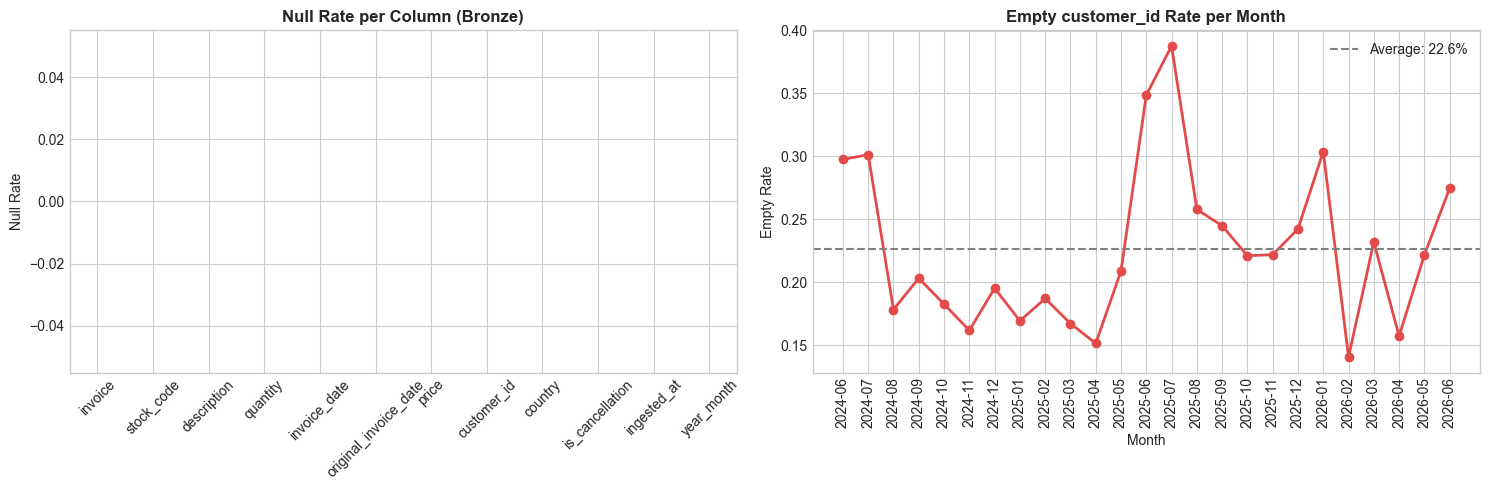


Average empty customer_id: 22.6%
Highest: 2025-07 = 38.8%
Lowest: 2026-02 = 14.1%


In [4]:
# Missing rate per column (Bronze)
print("=== Missing Values — Bronze ===")
missing = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_rate': df.isnull().mean(),
    'empty_str_count': (df.select_dtypes(include='object') == '').sum(),
    'empty_str_rate': (df.select_dtypes(include='object') == '').mean(),
})
display(missing)

# Bar chart: missing rate
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 3a. Null rate per column
null_rates = df.isnull().mean()
null_rates.plot(kind='bar', ax=axes[0], color=MISSING_COLOR, alpha=0.85)
axes[0].set_title('Null Rate per Column (Bronze)', fontweight='bold')
axes[0].set_ylabel('Null Rate')
axes[0].tick_params(axis='x', rotation=45)

# 3b. Empty customer_id rate per month (from ingestion log)
log = pd.read_csv(BRONZE_DIR / "_ingestion_log.csv")
log['null_rate'] = log['null_customer_count'] / log['row_count']
log = log.sort_values('year_month')

axes[1].plot(log['year_month'], log['null_rate'], marker='o', color=CANCEL_COLOR, linewidth=2)
axes[1].axhline(log['null_rate'].mean(), color='gray', linestyle='--', label=f"Average: {log['null_rate'].mean():.1%}")
axes[1].set_title('Empty customer_id Rate per Month', fontweight='bold')
axes[1].set_ylabel('Empty Rate')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAverage empty customer_id: {log['null_rate'].mean():.1%}")
print(f"Highest: {log.loc[log['null_rate'].idxmax(), 'year_month']} = {log['null_rate'].max():.1%}")
print(f"Lowest: {log.loc[log['null_rate'].idxmin(), 'year_month']} = {log['null_rate'].min():.1%}")

- `customer_id` is the ONLY column with missing values (~25% empty string)
- Empty rate fluctuates 18-35% by month — characteristic of the source (guest/anonymous purchases)
- Gold layer handles this with `customer_sk=0` (Unknown row in dim_customer)

### 4. Duplicate Detection

=== Duplicate Detection ===
Exact duplicates (Bronze): 34,150 (3.26%)
Duplicate (invoice, stock_code) pairs: 45,515

Top 5 invoices (most line items):
  Invoice 537434: 1,350 line items
  Invoice 538071: 1,304 line items
  Invoice 537638: 1,202 line items
  Invoice 537237: 1,194 line items
  Invoice 536876: 1,186 line items


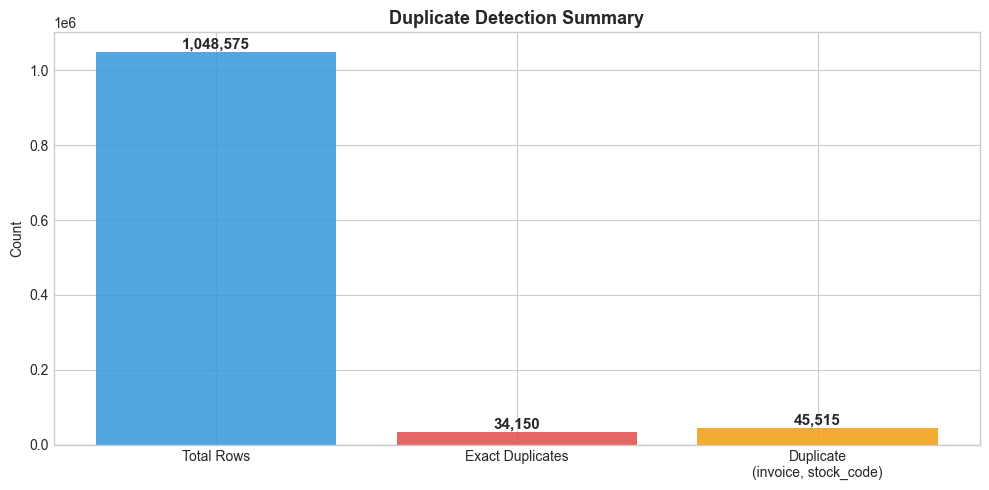

In [5]:
print("=== Duplicate Detection ===")

# Exact duplicates
bronze_exact_dup = df.duplicated().sum()
print(f"Exact duplicates (Bronze): {bronze_exact_dup:,} ({bronze_exact_dup/len(df):.2%})")

# Duplicate invoice + stock_code pairs
pair_dup = df.duplicated(subset=['invoice', 'stock_code']).sum()
print(f"Duplicate (invoice, stock_code) pairs: {pair_dup:,}")

# Top 5 invoices with most line items
top_invoices = df['invoice'].value_counts().head(5)
print(f"\nTop 5 invoices (most line items):")
for inv, cnt in top_invoices.items():
    print(f"  Invoice {inv}: {cnt:,} line items")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Total Rows', 'Exact Duplicates', 'Duplicate\n(invoice, stock_code)']
values = [len(df), bronze_exact_dup, pair_dup]
colors = [REVENUE_COLOR, CANCEL_COLOR, MISSING_COLOR]

bars = ax.bar(metrics, values, color=colors, alpha=0.85)
ax.bar_label(bars, labels=[f"{v:,}" for v in values], fontsize=11, fontweight='bold')
ax.set_title('Duplicate Detection Summary', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

- Duplicate invoice+stock_code pairs are **normal** — multi-line orders
- Exact duplicates are low — Silver removes them via `drop_duplicates()`
- Largest invoices can have ~1,000+ line items

### 5. Quantity & Price Distribution

=== Quantity & Price Stats ===

--- PURCHASE ---
  Quantity: mean=10.5, median=3.0, min=-9600, max=74215
  Price:    mean=3.89, median=2.10, min=-53594.36, max=25111.09

--- CANCELLATION ---
  Quantity: mean=-21.2, median=-2.0, min=-74215, max=1
  Price:    mean=43.76, median=2.95, min=0.01, max=38970.00


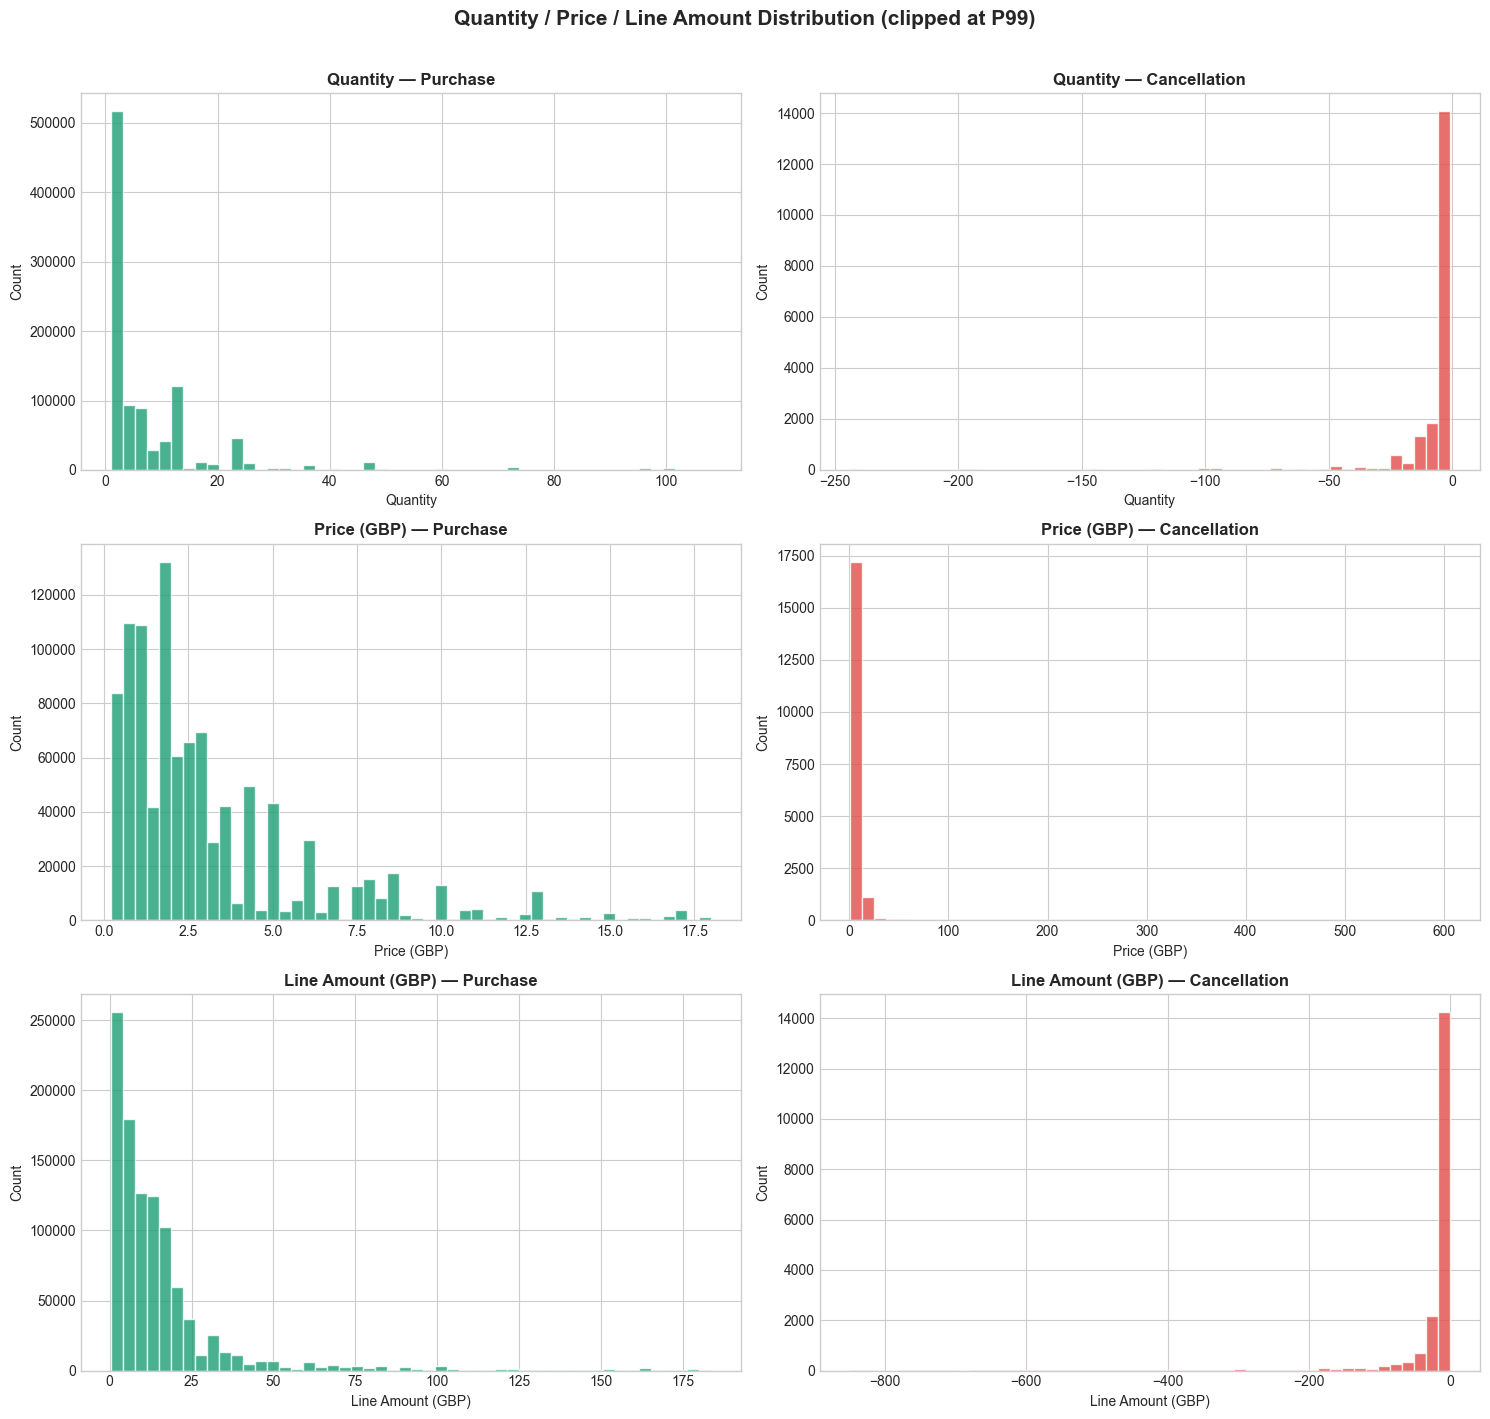

In [6]:
# Cast to numeric (comma decimals already handled in Bronze)
df['qty'] = pd.to_numeric(df['quantity'], errors='coerce')
df['prc'] = pd.to_numeric(df['price'], errors='coerce')
df['line_amt'] = df['qty'] * df['prc']

# Stats split by is_cancellation
print("=== Quantity & Price Stats ===")
for flag, label in [(False, 'PURCHASE'), (True, 'CANCELLATION')]:
    subset = df[df['is_cancellation'] == flag]
    print(f"\n--- {label} ---")
    print(f"  Quantity: mean={subset['qty'].mean():.1f}, median={subset['qty'].median():.1f}, "
          f"min={subset['qty'].min():.0f}, max={subset['qty'].max():.0f}")
    print(f"  Price:    mean={subset['prc'].mean():.2f}, median={subset['prc'].median():.2f}, "
          f"min={subset['prc'].min():.2f}, max={subset['prc'].max():.2f}")

# 3x2 grid: quantity / price / line_amount x (purchase vs cancellation)
fig, axes = plt.subplots(3, 2, figsize=(15, 14))
cols_plot = [('qty', 'Quantity'), ('prc', 'Price (GBP)'), ('line_amt', 'Line Amount (GBP)')]

for i, (col, title) in enumerate(cols_plot):
    for j, (flag, label, color) in enumerate([(False, 'Purchase', PURCHASE_COLOR), (True, 'Cancellation', CANCEL_COLOR)]):
        subset = df[df['is_cancellation'] == flag][col].dropna()
        # Clip extreme outliers for visualization
        clip_val = subset.quantile(0.99)
        clipped = subset[subset.between(subset.quantile(0.01), clip_val)]
        axes[i, j].hist(clipped, bins=50, color=color, alpha=0.8, edgecolor='white')
        axes[i, j].set_title(f'{title} — {label}', fontweight='bold')
        axes[i, j].set_xlabel(title)
        axes[i, j].set_ylabel('Count')

fig.suptitle('Quantity / Price / Line Amount Distribution (clipped at P99)', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

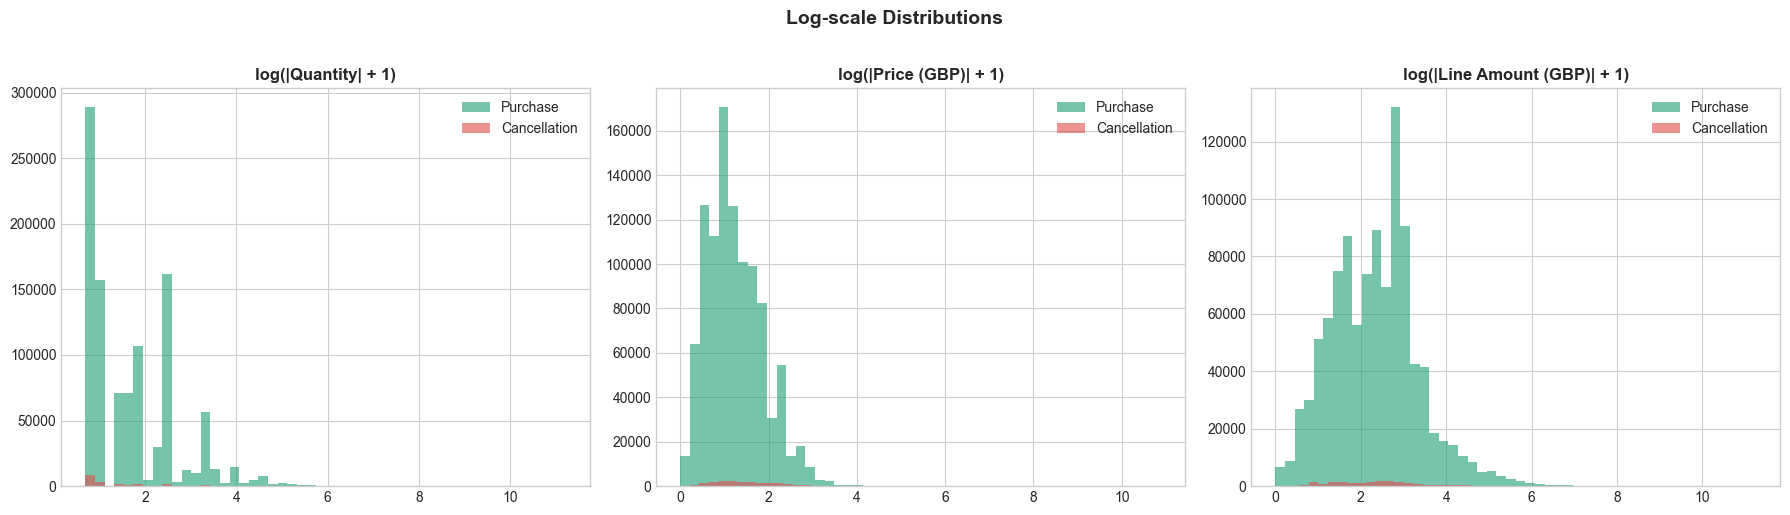

=== Extreme Outliers ===
Quantity > 1000: 496 rows
Price > 100: 1,926 rows
Price == 0: 6,166 rows

Skewness — Quantity: 8.95, Price: -75.45


In [7]:
# Log-scale histograms to examine distribution shape
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, title) in enumerate(cols_plot):
    purchases = df[(df['is_cancellation'] == False)][col].dropna()
    cancels = df[(df['is_cancellation'] == True)][col].dropna()
    
    axes[i].hist(np.log1p(purchases.abs()), bins=50, alpha=0.6, color=PURCHASE_COLOR, label='Purchase')
    axes[i].hist(np.log1p(cancels.abs()), bins=50, alpha=0.6, color=CANCEL_COLOR, label='Cancellation')
    axes[i].set_title(f'log(|{title}| + 1)', fontweight='bold')
    axes[i].legend()

fig.suptitle('Log-scale Distributions', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Outlier counts
print("=== Extreme Outliers ===")
print(f"Quantity > 1000: {(df['qty'].abs() > 1000).sum():,} rows")
print(f"Price > 100: {(df['prc'] > 100).sum():,} rows")
print(f"Price == 0: {(df['prc'] == 0).sum():,} rows")
print(f"\nSkewness — Quantity: {df['qty'].skew():.2f}, Price: {df['prc'].skew():.2f}")

- Distributions are **heavily right-skewed** — most transactions have small quantity, low price
- Cancellation = mirror image of purchase (negative quantity, similar price range)
- Log-transform produces near-normal distribution → suitable for ML features
- Outliers (bulk orders, high prices) are genuine transactions, not errors

### 6. Temporal Coverage & Monthly Trends

=== Temporal Coverage ===
Total months: 25
Range: 2024-06 → 2026-06
Total rows: 1,048,575


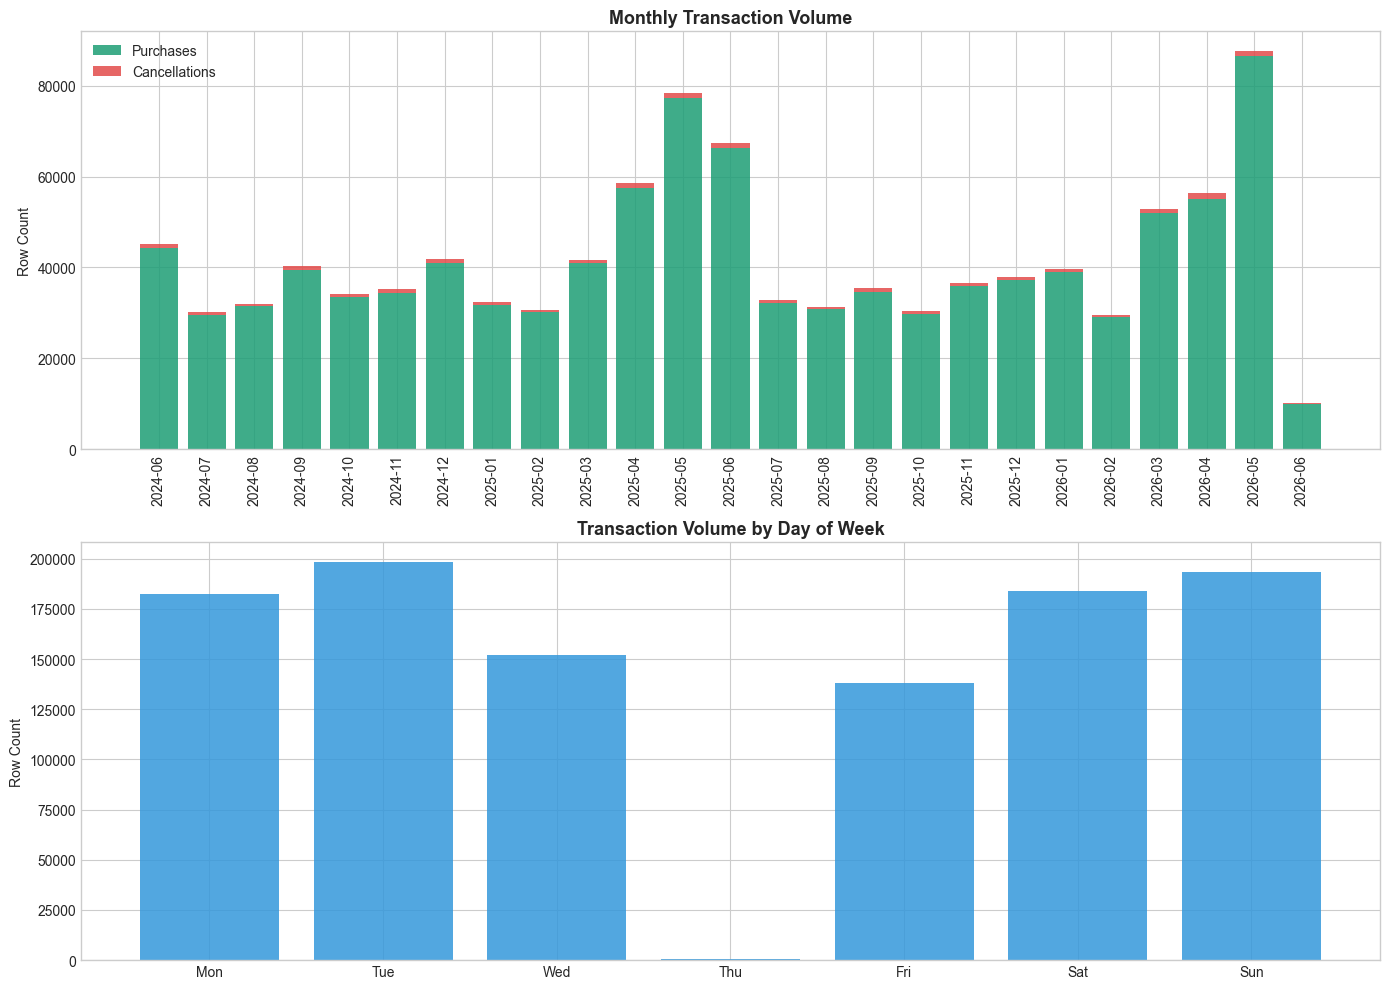

In [8]:
# Load ingestion log
log = pd.read_csv(BRONZE_DIR / "_ingestion_log.csv").sort_values('year_month')

print(f"=== Temporal Coverage ===")
print(f"Total months: {len(log)}")
print(f"Range: {log['year_month'].min()} → {log['year_month'].max()}")
print(f"Total rows: {log['row_count'].sum():,}")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 6a. Monthly volume -- stacked: cancellations vs normal
axes[0].bar(log['year_month'], log['row_count'] - log['cancellation_count'], 
            color=PURCHASE_COLOR, alpha=0.85, label='Purchases')
axes[0].bar(log['year_month'], log['cancellation_count'], 
            bottom=log['row_count'] - log['cancellation_count'],
            color=CANCEL_COLOR, alpha=0.85, label='Cancellations')
axes[0].set_title('Monthly Transaction Volume', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Row Count')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend()

# 6b. Day-of-week distribution
dow_counts = df['invoice_date'].dt.dayofweek.value_counts().sort_index()
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(dow_names[:len(dow_counts)], dow_counts.values, color=REVENUE_COLOR, alpha=0.85)
axes[1].set_title('Transaction Volume by Day of Week', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Row Count')

plt.tight_layout()
plt.show()

- 25 consecutive months with no gaps — full coverage
- Transaction volume fluctuates ~3x (low ~30K, high ~88K)
- Last month (2026-06) is partial — fewer rows
- Day-of-week: primarily Mon-Fri, very few weekend transactions

### 7. Cancellation Patterns

=== Cancellation Patterns ===
Overall cancellation rate: 1.84%

Per month range: 1.16% → 2.78%

Validation:
  All cancellations have 'C' prefix: True
  All cancellations have negative quantity: False


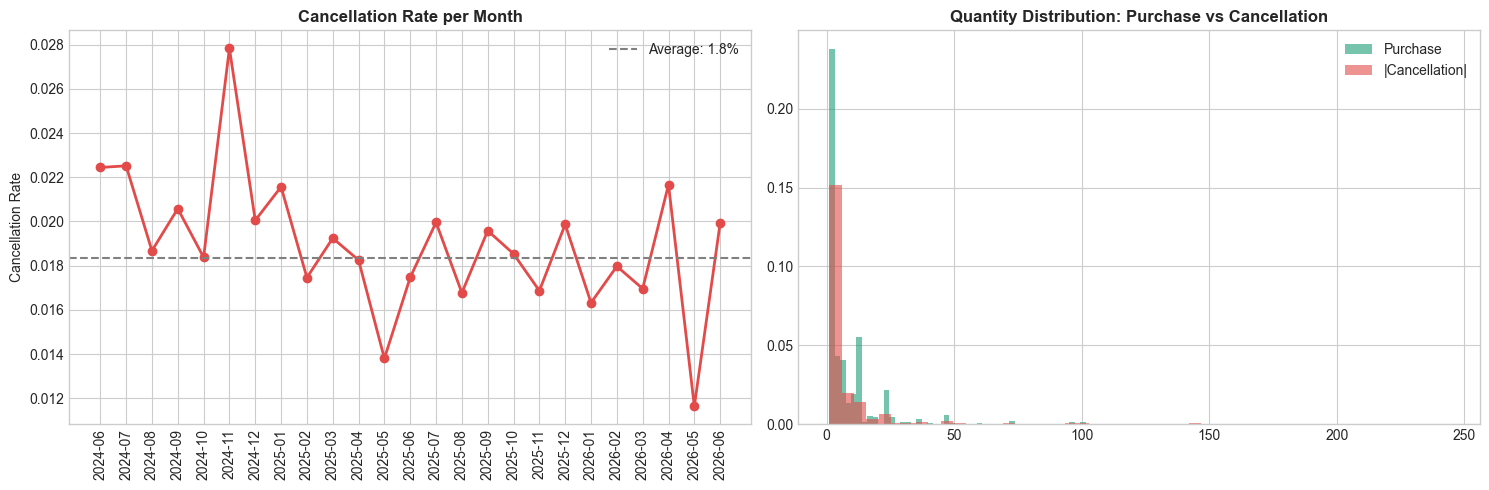

In [9]:
print("=== Cancellation Patterns ===")

# Overall rate
cancel_rate = df['is_cancellation'].mean()
print(f"Overall cancellation rate: {cancel_rate:.2%}")

# Per month
cancel_monthly = df.groupby(df['invoice_date'].dt.to_period('M'))['is_cancellation'].mean()
print(f"\nPer month range: {cancel_monthly.min():.2%} → {cancel_monthly.max():.2%}")

# Verify: all cancellations have 'C' prefix
cancel_rows = df[df['is_cancellation']]
c_prefix = cancel_rows['invoice'].str.startswith('C').all()
neg_qty = (cancel_rows['qty'] < 0).all()
print(f"\nValidation:")
print(f"  All cancellations have 'C' prefix: {c_prefix}")
print(f"  All cancellations have negative quantity: {neg_qty}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line chart: cancellation rate per month
cancel_monthly_dt = cancel_monthly.reset_index()
cancel_monthly_dt['invoice_date'] = cancel_monthly_dt['invoice_date'].astype(str)
axes[0].plot(cancel_monthly_dt['invoice_date'], cancel_monthly_dt['is_cancellation'], 
             marker='o', color=CANCEL_COLOR, linewidth=2)
axes[0].axhline(cancel_rate, color='gray', linestyle='--', label=f'Average: {cancel_rate:.1%}')
axes[0].set_title('Cancellation Rate per Month', fontweight='bold')
axes[0].set_ylabel('Cancellation Rate')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend()

# KDE: quantity distribution
purchases_qty = df[~df['is_cancellation']]['qty'].dropna()
purchases_qty = purchases_qty[purchases_qty.between(purchases_qty.quantile(0.01), purchases_qty.quantile(0.99))]
cancel_qty = df[df['is_cancellation']]['qty'].dropna().abs()
cancel_qty = cancel_qty[cancel_qty.between(cancel_qty.quantile(0.01), cancel_qty.quantile(0.99))]

axes[1].hist(purchases_qty, bins=50, alpha=0.6, color=PURCHASE_COLOR, label='Purchase', density=True)
axes[1].hist(cancel_qty, bins=50, alpha=0.6, color=CANCEL_COLOR, label='|Cancellation|', density=True)
axes[1].set_title('Quantity Distribution: Purchase vs Cancellation', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

- Cancellation rate is stable ~1.5-2.5% across months — no anomalous months
- All cancellations have 'C' prefix and negative quantity → flag is accurate
- Cancellation quantity distribution = mirror image of purchase

### 8. Country Distribution

=== Country Distribution ===
Total countries: 43

Top 10:


country
United Kingdom    963819
EIRE               17581
Germany            17327
France             14100
Netherlands         5054
Spain               3740
Switzerland         3189
Belgium             3056
Portugal            2566
Australia           1913
Name: count, dtype: int64


United Kingdom: 91.9% of transactions


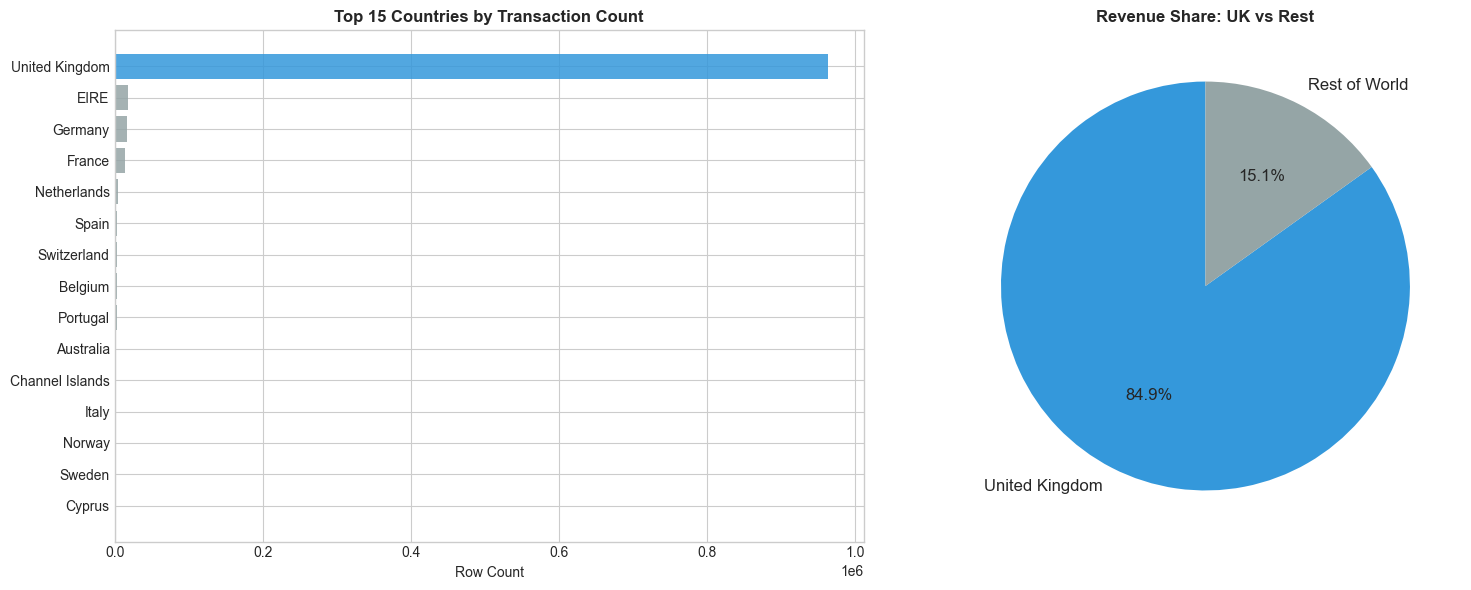

In [10]:
print("=== Country Distribution ===")
country_counts = df['country'].value_counts()
print(f"Total countries: {len(country_counts)}")
print(f"\nTop 10:")
display(country_counts.head(10))

uk_pct = country_counts.get('United Kingdom', 0) / len(df)
print(f"\nUnited Kingdom: {uk_pct:.1%} of transactions")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 8a. Top 15 countries bar chart
top15 = country_counts.head(15)
colors = [REVENUE_COLOR if c == 'United Kingdom' else '#95A5A6' for c in top15.index]
axes[0].barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], alpha=0.85)
axes[0].set_title('Top 15 Countries by Transaction Count', fontweight='bold')
axes[0].set_xlabel('Row Count')

# 8b. Revenue: UK vs Rest
df_with_rev = df.copy()
df_with_rev['revenue'] = df_with_rev['qty'] * df_with_rev['prc']
rev_by_country = df_with_rev.groupby('country')['revenue'].sum().sort_values(ascending=False)
uk_rev = rev_by_country.get('United Kingdom', 0)
other_rev = rev_by_country.sum() - uk_rev

axes[1].pie([uk_rev, other_rev], 
            labels=['United Kingdom', 'Rest of World'],
            colors=[REVENUE_COLOR, '#95A5A6'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Revenue Share: UK vs Rest', fontweight='bold')

plt.tight_layout()
plt.show()

- Dataset is **heavily UK-centric** — ~90% transactions and ~85% revenue
- 43 countries but most are negligible
- Key non-UK markets: France, Germany, EIRE (Ireland), Spain

### 9. Top Products & Customers — Pareto Analysis

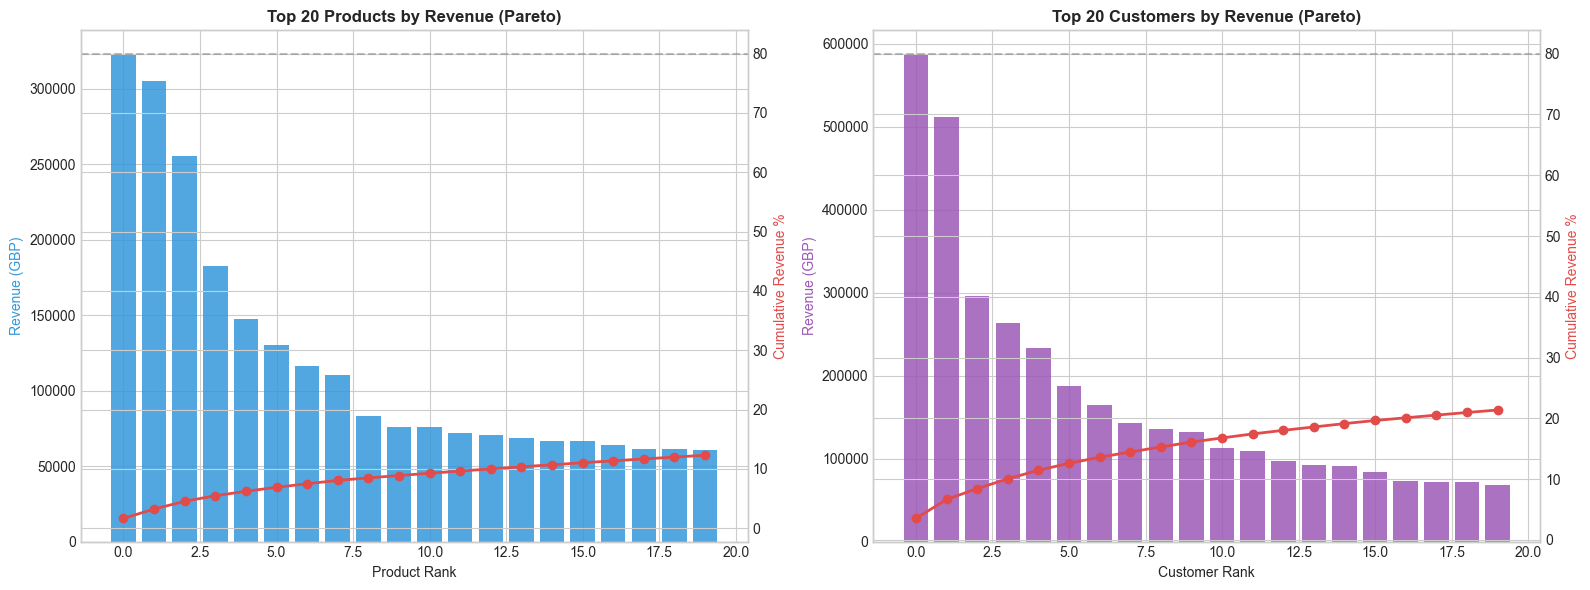

Unique products (positive revenue): 4,719
Unique customers (positive revenue): 5,824
  Top 276 customers (4.7%) generate 50% of revenue
  Top 1381 customers (23.7%) generate 80% of revenue


In [11]:
df_rev = df.copy()
df_rev['revenue'] = df_rev['qty'] * df_rev['prc']

# --- Pareto: Products ---
product_rev = df_rev.groupby('stock_code')['revenue'].sum().sort_values(ascending=False)
product_rev_positive = product_rev[product_rev > 0]
cum_pct_product = product_rev_positive.cumsum() / product_rev_positive.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 products
top20_prod = product_rev_positive.head(20)
axes[0].bar(range(len(top20_prod)), top20_prod.values, color=REVENUE_COLOR, alpha=0.85)
ax2 = axes[0].twinx()
ax2.plot(range(len(top20_prod)), cum_pct_product.head(20).values * 100, 
         color=CANCEL_COLOR, marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Revenue %', color=CANCEL_COLOR)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Top 20 Products by Revenue (Pareto)', fontweight='bold')
axes[0].set_xlabel('Product Rank')
axes[0].set_ylabel('Revenue (GBP)', color=REVENUE_COLOR)

# --- Pareto: Customers ---
cust_rev = df_rev[df_rev['customer_id'] != ''].groupby('customer_id')['revenue'].sum()
cust_rev = cust_rev.sort_values(ascending=False)
cust_rev_positive = cust_rev[cust_rev > 0]
cum_pct_cust = cust_rev_positive.cumsum() / cust_rev_positive.sum()

top20_cust = cust_rev_positive.head(20)
axes[1].bar(range(len(top20_cust)), top20_cust.values, color=VOLUME_COLOR, alpha=0.85)
ax3 = axes[1].twinx()
ax3.plot(range(len(top20_cust)), cum_pct_cust.head(20).values * 100, 
         color=CANCEL_COLOR, marker='o', linewidth=2)
ax3.set_ylabel('Cumulative Revenue %', color=CANCEL_COLOR)
ax3.axhline(80, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Top 20 Customers by Revenue (Pareto)', fontweight='bold')
axes[1].set_xlabel('Customer Rank')
axes[1].set_ylabel('Revenue (GBP)', color=VOLUME_COLOR)

plt.tight_layout()
plt.show()

# Pareto stats
print(f"Unique products (positive revenue): {len(product_rev_positive):,}")
print(f"Unique customers (positive revenue): {len(cust_rev_positive):,}")
for pct in [50, 80]:
    n_cust = (cum_pct_cust <= pct / 100).sum() + 1
    print(f"  Top {n_cust} customers ({n_cust/len(cust_rev_positive):.1%}) generate {pct}% of revenue")

- Strong Pareto effect — a small number of customers generate the majority of revenue
- Validates the business case for RFM segmentation and targeted marketing
- Recommendation: focus retention efforts on top 20% of customers

### 10. Conclusions & Recommendations for Silver Layer

| Finding | Impact | Recommendation for Silver |
|---|---|---|
| ~25% empty customer_id | Cannot compute RFM for these rows | Keep as-is, Gold routes to customer_sk=0 |
| Heavy outliers (qty/price) | Skews aggregates | Log-transform for ML features |
| Price=0 rows (non-cancellation) | Likely junk/adjustments | Silver correctly filters these rows |
| Right-skewed distributions | ML needs normalization | Log-transform features in Gold/ML |
| Strong Pareto effect | Validates segmentation approach | RFM quintiles will capture this naturally |
| Stable ~2% cancellation rate | Low noise | cancellation_rate per customer is a valid feature |
| 43 countries, UK dominant | Low cardinality | dim_country is appropriate, country feature has low variance |